In [1]:
pip install scikit-learn pandas numpy matplotlib joblib

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, roc_auc_score, ConfusionMatrixDisplay
)

print("All libraries imported successfully!")

All libraries imported successfully!


In [4]:
def generate_dataset(n_samples=2000, random_state=42):
    rng = np.random.default_rng(random_state)
    rows = []

    for _ in range(n_samples):
        emergency = rng.random() < 0.35

        if emergency:
            pattern = rng.choice(['cardiac', 'respiratory', 'sepsis', 'mixed'])

            if pattern == 'cardiac':
                hr   = rng.choice([rng.uniform(130, 180), rng.uniform(20, 45)])
                sbp  = rng.choice([rng.uniform(160, 200), rng.uniform(60, 85)])
                dbp  = rng.choice([rng.uniform(100, 130), rng.uniform(30, 55)])
                spo2 = rng.uniform(88, 94)
                rr   = rng.uniform(20, 30)
                temp = rng.uniform(36.0, 37.5)
            elif pattern == 'respiratory':
                hr   = rng.uniform(100, 140)
                sbp  = rng.uniform(90, 130)
                dbp  = rng.uniform(55, 85)
                spo2 = rng.uniform(80, 91)
                rr   = rng.uniform(28, 40)
                temp = rng.uniform(36.5, 38.5)
            elif pattern == 'sepsis':
                hr   = rng.uniform(100, 150)
                sbp  = rng.uniform(70, 100)
                dbp  = rng.uniform(40, 65)
                spo2 = rng.uniform(88, 95)
                rr   = rng.uniform(22, 35)
                temp = rng.choice([rng.uniform(38.5, 41.0), rng.uniform(34.0, 36.0)])
            else:
                hr   = rng.uniform(110, 160)
                sbp  = rng.uniform(75, 160)
                dbp  = rng.uniform(45, 105)
                spo2 = rng.uniform(82, 92)
                rr   = rng.uniform(22, 38)
                temp = rng.uniform(35.0, 40.5)
        else:
            hr   = rng.uniform(58, 102)
            sbp  = rng.uniform(90, 135)
            dbp  = rng.uniform(58, 85)
            spo2 = rng.uniform(94, 100)
            rr   = rng.uniform(11, 21)
            temp = rng.uniform(36.0, 37.4)

        rows.append({
            'heart_rate':        round(hr,   1),
            'systolic_bp':       round(sbp,  1),
            'diastolic_bp':      round(dbp,  1),
            'oxygen_saturation': round(spo2, 1),
            'respiratory_rate':  round(rr,   1),
            'temperature':       round(temp, 2),
            'label':             'EMERGENCY' if emergency else 'STABLE'
        })

    return pd.DataFrame(rows)

df = generate_dataset(2000)
df.to_csv('patient_vitals_dataset.csv', index=False)
print(f"Dataset created: {len(df)} records")
print(df['label'].value_counts())
df.head(10)

Dataset created: 2000 records
STABLE       1293
EMERGENCY     707
Name: label, dtype: int64


,heart_rate,systolic_bp,diastolic_bp,oxygen_saturation,respiratory_rate,temperature,label
0,77.3,128.6,76.8,94.6,20.8,37.07,STABLE
1,63.6,110.3,68.0,99.6,17.4,37.15,STABLE
2,68.0,115.0,59.7,99.0,17.3,37.06,STABLE
3,100.7,130.2,79.0,95.2,15.7,36.06,STABLE
4,137.2,99.0,48.1,90.6,28.1,34.26,EMERGENCY
5,68.0,120.1,69.8,99.0,18.0,36.44,STABLE
6,93.4,107.4,65.8,98.1,12.4,36.28,STABLE
7,143.2,134.9,91.8,86.6,31.1,35.77,EMERGENCY
8,143.4,115.0,78.9,89.6,32.2,38.04,EMERGENCY
9,71.4,91.4,69.8,95.3,15.1,37.19,STABLE


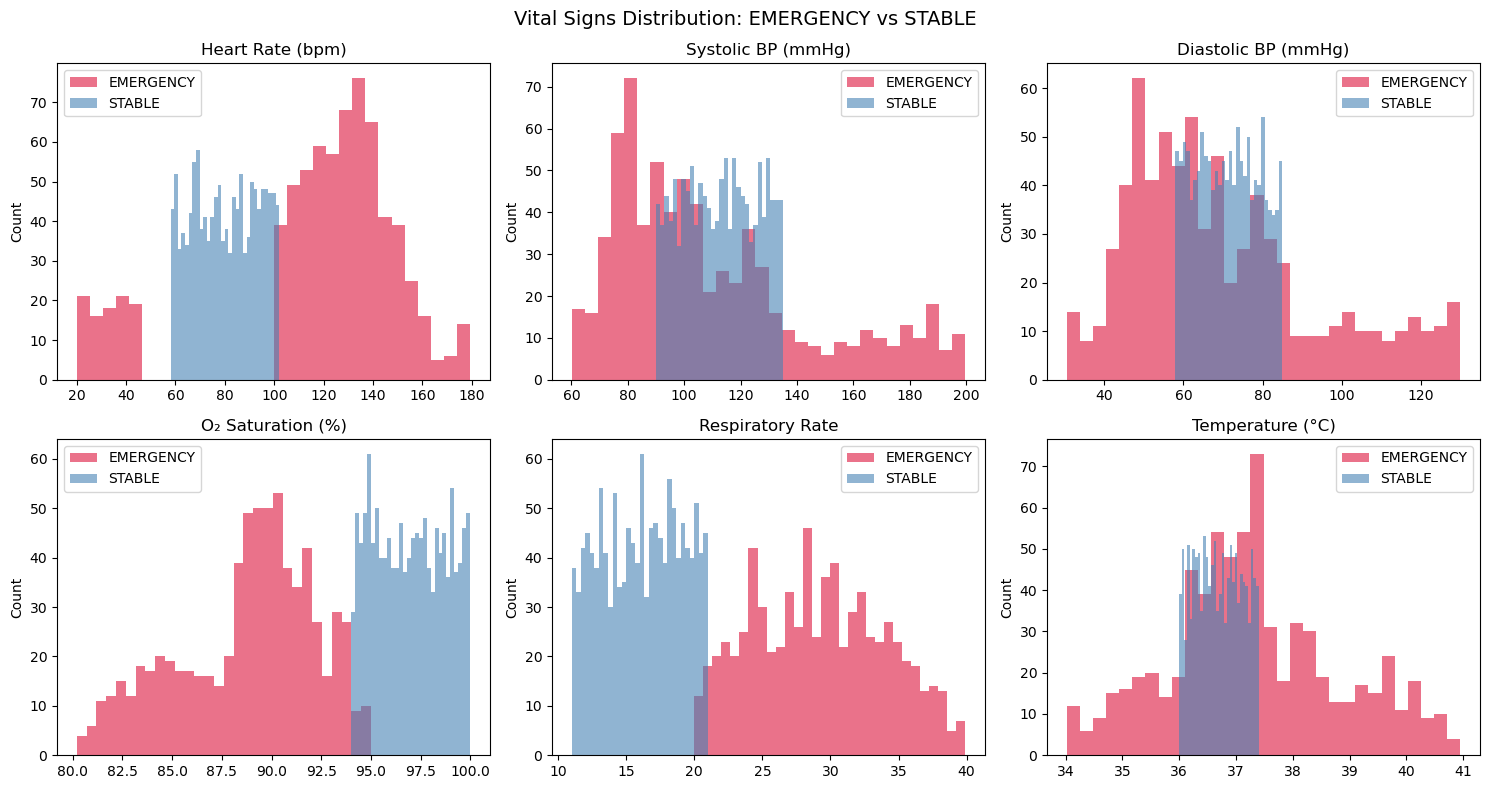

Chart saved as vitals_distribution.png


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Vital Signs Distribution: EMERGENCY vs STABLE', fontsize=14)

vitals = ['heart_rate', 'systolic_bp', 'diastolic_bp',
          'oxygen_saturation', 'respiratory_rate', 'temperature']
titles = ['Heart Rate (bpm)', 'Systolic BP (mmHg)', 'Diastolic BP (mmHg)',
          'O₂ Saturation (%)', 'Respiratory Rate', 'Temperature (°C)']

colors = {'STABLE': 'steelblue', 'EMERGENCY': 'crimson'}

for ax, vital, title in zip(axes.flat, vitals, titles):
    for label, grp in df.groupby('label'):
        ax.hist(grp[vital], bins=30, alpha=0.6, label=label, color=colors[label])
    ax.set_title(title)
    ax.legend()
    ax.set_ylabel('Count')

plt.tight_layout()
plt.savefig('vitals_distribution.png', dpi=150)
plt.show()
print("Chart saved as vitals_distribution.png")


In [6]:
FEATURES = [
    'heart_rate', 'systolic_bp', 'diastolic_bp',
    'oxygen_saturation', 'respiratory_rate', 'temperature',
    'pulse_pressure', 'shock_index', 'map',
    'spo2_flag', 'tachycardia_flag', 'hypo_bp_flag',
    'fever_flag', 'tachypnea_flag'
]

def engineer_features(df):
    df = df.copy()
    df['pulse_pressure']   = df['systolic_bp'] - df['diastolic_bp']
    df['shock_index']      = df['heart_rate'] / df['systolic_bp'].clip(lower=1)
    df['map']              = (df['systolic_bp'] + 2 * df['diastolic_bp']) / 3
    df['spo2_flag']        = (df['oxygen_saturation'] < 94).astype(int)
    df['tachycardia_flag'] = (df['heart_rate'] > 100).astype(int)
    df['hypo_bp_flag']     = (df['systolic_bp'] < 90).astype(int)
    df['fever_flag']       = (df['temperature'] > 38.5).astype(int)
    df['tachypnea_flag']   = (df['respiratory_rate'] > 20).astype(int)
    return df

df_eng = engineer_features(df)
X = df_eng[FEATURES]
y = (df_eng['label'] == 'EMERGENCY').astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
model.fit(X_train_sc, y_train)
print("Model trained successfully!")

Model trained successfully!


In [7]:
y_pred = model.predict(X_test_sc)
y_prob = model.predict_proba(X_test_sc)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)
cv  = cross_val_score(model, scaler.transform(X), y, cv=5, scoring='accuracy')

print("=" * 45)
print("         MODEL PERFORMANCE REPORT")
print("=" * 45)
print(f"  Accuracy:           {acc*100:.2f}%")
print(f"  AUC-ROC Score:      {auc:.4f}")
print(f"  5-Fold CV Accuracy: {cv.mean()*100:.2f}% ± {cv.std()*100:.2f}%")
print("=" * 45)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['STABLE', 'EMERGENCY']))

         MODEL PERFORMANCE REPORT
  Accuracy:           100.00%
  AUC-ROC Score:      1.0000
  5-Fold CV Accuracy: 100.00% ± 0.00%

Classification Report:
              precision    recall  f1-score   support

      STABLE       1.00      1.00      1.00       259
   EMERGENCY       1.00      1.00      1.00       141

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



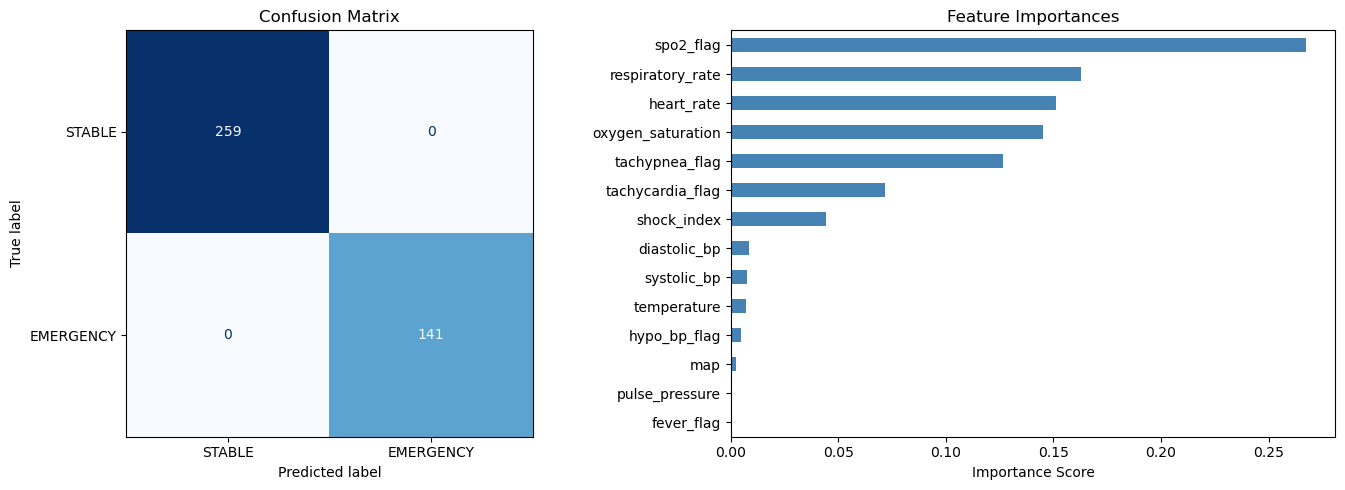

Evaluation chart saved as model_evaluation.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['STABLE', 'EMERGENCY'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix')

# Feature importances
importances = pd.Series(model.feature_importances_, index=FEATURES).sort_values()
importances.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Feature Importances')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150)
plt.show()
print("Evaluation chart saved as model_evaluation.png")

In [9]:
def predict_patient(vitals: dict):
    df_input = pd.DataFrame([vitals])
    df_input = engineer_features(df_input)
    X_input  = df_input[FEATURES]
    X_sc     = scaler.transform(X_input)

    label = model.predict(X_sc)[0]
    prob  = model.predict_proba(X_sc)[0]

    result = 'EMERGENCY' if label == 1 else 'STABLE'
    print(f"  Prediction:        {result}")
    print(f"  Emergency risk:    {prob[1]*100:.1f}%")
    print(f"  Stable confidence: {prob[0]*100:.1f}%")
    return result

# Test cases
test_cases = [
    ("Healthy Adult",    dict(heart_rate=72,  systolic_bp=118, diastolic_bp=76,  oxygen_saturation=98, respiratory_rate=15, temperature=36.8)),
    ("Cardiac Crisis",   dict(heart_rate=155, systolic_bp=78,  diastolic_bp=45,  oxygen_saturation=89, respiratory_rate=32, temperature=37.1)),
    ("Septic Shock",     dict(heart_rate=125, systolic_bp=82,  diastolic_bp=48,  oxygen_saturation=91, respiratory_rate=28, temperature=39.6)),
    ("Borderline Case",  dict(heart_rate=108, systolic_bp=95,  diastolic_bp=62,  oxygen_saturation=93, respiratory_rate=22, temperature=38.8)),
]

for name, vitals in test_cases:
    print(f"\n[{name}]")
    predict_patient(vitals)


[Healthy Adult]
  Prediction:        STABLE
  Emergency risk:    0.0%
  Stable confidence: 100.0%

[Cardiac Crisis]
  Prediction:        EMERGENCY
  Emergency risk:    100.0%
  Stable confidence: 0.0%

[Septic Shock]
  Prediction:        EMERGENCY
  Emergency risk:    100.0%
  Stable confidence: 0.0%

[Borderline Case]
  Prediction:        EMERGENCY
  Emergency risk:    100.0%
  Stable confidence: 0.0%


In [10]:
joblib.dump(model,  'emergency_model.pkl')
joblib.dump(scaler, 'emergency_scaler.pkl')
df.to_csv('patient_vitals_dataset.csv', index=False)

print("Files saved:")
print("  emergency_model.pkl")
print("  emergency_scaler.pkl")
print("  patient_vitals_dataset.csv")
print("  vitals_distribution.png")
print("  model_evaluation.png")

Files saved:
  emergency_model.pkl
  emergency_scaler.pkl
  patient_vitals_dataset.csv
  vitals_distribution.png
  model_evaluation.png
